In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [17]:
# 1. Load Data & Filter for France 2024
df = pd.read_csv(r'C:\Users\Asus\Documents\GitHub\Project_CO2\\FR_EEA_2024\FR_EEA_data_2024.csv', sep=None,
    engine="python",
    encoding="latin1",
)

# Preview top rows and summary stats
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.info()
df.head()

Shape: (1820622, 37)
Columns: ['ï»¿ID', 'Country', 'VFN', 'Mp', 'Mh', 'Man', 'MMS', 'Tan', 'T', 'Va', 'Ve', 'Mk', 'Cn', 'Ct', 'Cr', 'r', 'm (kg)', 'Mt', 'Enedc (g/km)', 'Ewltp (g/km)', 'Ft', 'Fm', 'ec (cm3)', 'ep (KW)', 'z (Wh/km)', 'IT', 'Ernedc (g/km)', 'Erwltp (g/km)', 'De', 'Vf', 'Status', 'year', 'Date of registration', 'Fuel consumption', 'ech', 'RLFI', 'Electric range (km)']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1820622 entries, 0 to 1820621
Data columns (total 37 columns):
 #   Column                Dtype  
---  ------                -----  
 0   ï»¿ID                 int64  
 1   Country               object 
 2   VFN                   object 
 3   Mp                    object 
 4   Mh                    object 
 5   Man                   object 
 6   MMS                   float64
 7   Tan                   object 
 8   T                     object 
 9   Va                    object 
 10  Ve                    object 
 11  Mk                    object 
 12  Cn     

,ï»¿ID,Country,VFN,Mp,Mh,Man,MMS,Tan,T,Va,...,Erwltp (g/km),De,Vf,Status,year,Date of registration,Fuel consumption,ech,RLFI,Electric range (km)
0,146604101,FR,IP-ZKX____REDU576C-VR3,STELLANTIS,STELLANTIS AUTO,STELLANTIS AUTO SAS,NaN,e2*2007/46*0639*32,U,H,...,NaN,NaN,NaN,P,2024,2024-10-08,NaN,AX,RL-___CMP_REDU5760-VR3,362.0
1,146604102,FR,IP-MQB37AS_B0_1140-WAU,VOLKSWAGEN,AUDI AG,AUDI AG,NaN,e1*2007/46*1900*35,F3,SDXDBF1,...,2.03,NaN,NaN,P,2024,2024-12-20,7.0,Euro 6 EA,RL-DQ381_7F_22_019-WAU,NaN
2,146604103,FR,IP-4_1246-JSA-1,VOLVO CARS POLESTAR SUZUKI,SUZUKI MOTOR CORPORATION,SUZUKI MOTOR CORPORATION,NaN,e4*2007/46*1205*14,AZ,CA3S,...,1.84,NaN,NaN,P,2024,2024-03-20,4.7,Euro 6 AP,RL-4_AZ5102-JSA-1,NaN
3,146604104,FR,IP-EA9YAII4BH0AT00-WP1,VOLKSWAGEN,PORSCHE,DR ING HCF PORSCHE AG,NaN,e13*2007/46*0900*17,9YA,CL22,...,NaN,NaN,NaN,P,2024,2024-12-30,1.5,Euro 6 EA,RL-9YAII4AT80ZZZ02-WP1,74.0
4,146604105,FR,IP-JBB1N4PDB1A_000-VF1,RENAULT-NISSAN-MITSUBISHI,RENAULT,RENAULT SAS,NaN,e2*2007/46*0684*29,RJB,DH2,...,1.07,NaN,NaN,P,2024,2024-10-21,4.7,Euro 6 EA,RL-JBDDB1C_350_000-VF1,NaN


In [18]:
# Select columns from index 19 ("Ewltp (g/km)") to 36 ("Electric range (km)")
# Python slicing includes index 19 up to 37 (exclusive)
cols_selected = df.columns[19:37]
df_subset = df[cols_selected].copy()

print(f"Subset Shape: {df_subset.shape}")
print("Selected Columns:")

for i, col in enumerate(df_subset.columns, start=19):
    print(f"  [{i}] {col}")

Subset Shape: (1820622, 18)
Selected Columns:
  [19] Ewltp (g/km)
  [20] Ft
  [21] Fm
  [22] ec (cm3)
  [23] ep (KW)
  [24] z (Wh/km)
  [25] IT
  [26] Ernedc (g/km)
  [27] Erwltp (g/km)
  [28] De
  [29] Vf
  [30] Status
  [31] year
  [32] Date of registration
  [33] Fuel consumption
  [34] ech
  [35] RLFI
  [36] Electric range (km)


In [19]:
df_subset.head()

,Ewltp (g/km),Ft,Fm,ec (cm3),ep (KW),z (Wh/km),IT,Ernedc (g/km),Erwltp (g/km),De,Vf,Status,year,Date of registration,Fuel consumption,ech,RLFI,Electric range (km)
0,0,electric,E,NaN,100,154.0,NaN,NaN,NaN,NaN,NaN,P,2024,2024-10-08,NaN,AX,RL-___CMP_REDU5760-VR3,362.0
1,160,petrol,M,1498.0,110,NaN,E13 29 37,NaN,2.03,NaN,NaN,P,2024,2024-12-20,7.0,Euro 6 EA,RL-DQ381_7F_22_019-WAU,NaN
2,106,petrol,H,1197.0,61,NaN,E4 33 37,NaN,1.84,NaN,NaN,P,2024,2024-03-20,4.7,Euro 6 AP,RL-4_AZ5102-JSA-1,NaN
3,33,petrol/electric,P,2995.0,224,330.0,NaN,NaN,NaN,NaN,NaN,P,2024,2024-12-30,1.5,Euro 6 EA,RL-9YAII4AT80ZZZ02-WP1,74.0
4,106,petrol,H,1598.0,69,NaN,E9 37,NaN,1.07,NaN,NaN,P,2024,2024-10-21,4.7,Euro 6 EA,RL-JBDDB1C_350_000-VF1,NaN


In [20]:
# Total count of fully duplicate rows in the subset
print("Exact duplicate rows:", df_subset.duplicated().sum())

# View all duplicate rows side-by-side
df_subset[df_subset.duplicated(keep=False)]

Exact duplicate rows: 1381638


,Ewltp (g/km),Ft,Fm,ec (cm3),ep (KW),z (Wh/km),IT,Ernedc (g/km),Erwltp (g/km),De,Vf,Status,year,Date of registration,Fuel consumption,ech,RLFI,Electric range (km)
0,0,electric,E,NaN,100,154.0,NaN,NaN,NaN,NaN,NaN,P,2024,2024-10-08,NaN,AX,RL-___CMP_REDU5760-VR3,362.0
1,160,petrol,M,1498.0,110,NaN,E13 29 37,NaN,2.03,NaN,NaN,P,2024,2024-12-20,7.0,Euro 6 EA,RL-DQ381_7F_22_019-WAU,NaN
2,106,petrol,H,1197.0,61,NaN,E4 33 37,NaN,1.84,NaN,NaN,P,2024,2024-03-20,4.7,Euro 6 AP,RL-4_AZ5102-JSA-1,NaN
3,33,petrol/electric,P,2995.0,224,330.0,NaN,NaN,NaN,NaN,NaN,P,2024,2024-12-30,1.5,Euro 6 EA,RL-9YAII4AT80ZZZ02-WP1,74.0
4,106,petrol,H,1598.0,69,NaN,E9 37,NaN,1.07,NaN,NaN,P,2024,2024-10-21,4.7,Euro 6 EA,RL-JBDDB1C_350_000-VF1,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1820616,118,petrol,M,1199.0,74,NaN,E2 29 37,NaN,2.12,NaN,NaN,P,2024,2024-11-27,5.2,Euro 6 EA,RL-___CMP2MB6_5025-VR3,NaN
1820617,105,petrol,H,1199.0,96,NaN,E9 37,NaN,0.69,NaN,NaN,P,2024,2024-12-06,4.6,Euro 6 EA,RL-HNADB1A_450_000-VF1,NaN
1820619,119,petrol,M,999.0,70,NaN,E9 29 37,NaN,1.90,NaN,NaN,P,2024,2024-02-21,5.2,Euro 6 AP,RL-MQ200_5F_20_001-WVW-1,NaN
1820620,146,diesel,M,1499.0,96,NaN,E2 29 37,NaN,1.20,NaN,NaN,P,2024,2024-10-25,5.6,Euro 6 EA,RL-___MP2LATN84051-VR3,NaN


In [21]:
# out of 1,820,622 rows, 1,381,638 rows (75.8%) share identical technical configurations across all 18 
# selected columns. This happens because EEA datasets record individual vehicle registrations rather than 
# unique vehicle models—meaning every identical car registered produces a matching row.

In [22]:
# Group by all 18 columns to get a frequency count of identical configurations
df_subset.value_counts(dropna=False).reset_index(name='registration_count')

,Ewltp (g/km),Ft,Fm,ec (cm3),ep (KW),z (Wh/km),IT,Ernedc (g/km),Erwltp (g/km),De,Vf,Status,year,Date of registration,Fuel consumption,ech,RLFI,Electric range (km),registration_count
0,100,petrol,H,1498.0,75,NaN,NaN,NaN,NaN,NaN,NaN,P,2024,2024-12-23,4.4,Euro 6 EA,RL-ZP22_2023_02-LSJ,NaN,2049
1,0,electric,E,NaN,83,171.0,NaN,NaN,NaN,NaN,NaN,P,2024,2024-09-30,NaN,AX,RL-___SMARREDUSG60-VR3,325.0,1320
2,123,petrol,M,1199.0,61,NaN,E2 28 29,NaN,1.91,NaN,NaN,P,2024,2024-03-29,5.5,Euro 6 AP,RL-___BVH1MA5_1010-VF3-0,NaN,974
3,128,petrol,M,1199.0,74,NaN,E2 29 37,NaN,1.96,NaN,NaN,P,2024,2024-10-31,5.7,Euro 6 EA,RL-___SMARMB6_SA20-VR3,NaN,966
4,120,petrol,M,1199.0,55,NaN,E2 29 37,NaN,2.00,NaN,NaN,P,2024,2024-10-31,5.4,Euro 6 EA,RL-___CMP_MA5_5015-VR3,NaN,907
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
438979,105,petrol,H,1987.0,112,NaN,E6 37,NaN,0.59,NaN,NaN,P,2024,2024-07-04,4.7,Euro 6 AP,RL-0077-JT1-1,NaN,1
438980,105,petrol,H,1987.0,112,NaN,E6 37,NaN,0.59,NaN,NaN,P,2024,2024-07-04,4.6,Euro 6 AP,RL-0077-JT1-1,NaN,1
438981,105,petrol,H,1987.0,112,NaN,E6 37,NaN,0.59,NaN,NaN,P,2024,2024-07-02,4.7,Euro 6 AP,RL-0077-JT1-1,NaN,1
438982,105,petrol,H,1987.0,112,NaN,E6 37,NaN,0.59,NaN,NaN,P,2024,2024-06-27,4.6,Euro 6 AP,RL-0077-JT1-1,NaN,1


In [23]:
# Display duplicates sorted by all columns so identical rows sit next to each other
df_subset[df_subset.duplicated(keep=False)].sort_values(by=list(df_subset.columns))

,Ewltp (g/km),Ft,Fm,ec (cm3),ep (KW),z (Wh/km),IT,Ernedc (g/km),Erwltp (g/km),De,Vf,Status,year,Date of registration,Fuel consumption,ech,RLFI,Electric range (km)
388704,0,electric,E,NaN,28,131.0,NaN,NaN,NaN,NaN,NaN,P,2024,2024-01-26,NaN,AX,RL-001-SD8-1,88.0
1649718,0,electric,E,NaN,28,131.0,NaN,NaN,NaN,NaN,NaN,P,2024,2024-01-26,NaN,AX,RL-001-SD8-1,88.0
428519,0,electric,E,NaN,28,132.0,NaN,NaN,NaN,NaN,NaN,P,2024,2024-02-14,NaN,AX,RL-001-SD8-1,88.0
867191,0,electric,E,NaN,28,132.0,NaN,NaN,NaN,NaN,NaN,P,2024,2024-02-14,NaN,AX,RL-001-SD8-1,88.0
1538513,0,electric,E,NaN,28,132.0,NaN,NaN,NaN,NaN,NaN,P,2024,2024-02-14,NaN,AX,RL-001-SD8-1,88.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
978099,393,petrol,M,6496.0,529,NaN,NaN,NaN,NaN,NaN,NaN,P,2024,2024-07-05,17.3,Euro 6 AP,RL-F175AHA-ZFF-1,NaN
1301272,393,petrol,M,6496.0,529,NaN,NaN,NaN,NaN,NaN,NaN,P,2024,2024-07-05,17.3,Euro 6 AP,RL-F175AHA-ZFF-1,NaN
71674,393,petrol,M,6496.0,529,NaN,NaN,NaN,NaN,NaN,NaN,P,2024,2024-10-03,17.3,Euro 6 EA,RL-F175AHA-ZFF-1,NaN
398263,393,petrol,M,6496.0,529,NaN,NaN,NaN,NaN,NaN,NaN,P,2024,2024-10-03,17.3,Euro 6 EA,RL-F175AHA-ZFF-1,NaN


In [24]:
# Keeping only the first instance of each identical row
df_unique_specs = df_subset.drop_duplicates()

print("Original shape:", df_subset.shape)
print("Unique configurations shape:", df_unique_specs.shape)

Original shape: (1820622, 18)
Unique configurations shape: (438984, 18)


In [25]:
df_unique_specs.head()

,Ewltp (g/km),Ft,Fm,ec (cm3),ep (KW),z (Wh/km),IT,Ernedc (g/km),Erwltp (g/km),De,Vf,Status,year,Date of registration,Fuel consumption,ech,RLFI,Electric range (km)
0,0,electric,E,NaN,100,154.0,NaN,NaN,NaN,NaN,NaN,P,2024,2024-10-08,NaN,AX,RL-___CMP_REDU5760-VR3,362.0
1,160,petrol,M,1498.0,110,NaN,E13 29 37,NaN,2.03,NaN,NaN,P,2024,2024-12-20,7.0,Euro 6 EA,RL-DQ381_7F_22_019-WAU,NaN
2,106,petrol,H,1197.0,61,NaN,E4 33 37,NaN,1.84,NaN,NaN,P,2024,2024-03-20,4.7,Euro 6 AP,RL-4_AZ5102-JSA-1,NaN
3,33,petrol/electric,P,2995.0,224,330.0,NaN,NaN,NaN,NaN,NaN,P,2024,2024-12-30,1.5,Euro 6 EA,RL-9YAII4AT80ZZZ02-WP1,74.0
4,106,petrol,H,1598.0,69,NaN,E9 37,NaN,1.07,NaN,NaN,P,2024,2024-10-21,4.7,Euro 6 EA,RL-JBDDB1C_350_000-VF1,NaN


In [26]:

# Define the dictionary
eea_data_dictionary = {
    "Column Name": [
        "Ewltp (g/km)", "Ft", "Fm", "ec (cm3)", "ep (KW)", "z (Wh/km)", 
        "IT", "Ernedc (g/km)", "Erwltp (g/km)", "De", "Vf", "Status", 
        "year", "Date of registration", "Fuel consumption", "ech", "RLFI", "Electric range (km)"
    ],
    "Description": [
        "Specific CO2 emissions measured under official WLTP test cycle",
        "Main fuel type used by the vehicle (e.g., petrol, diesel, electric)",
        "Operational fuel mode (M: Monovalent, E: Electric, H: Hybrid, P: Plug-in)",
        "Engine capacity / displacement volume",
        "Engine maximum net power output",
        "Electric energy consumption rate",
        "Approved eco-innovation technology code",
        "CO2 emissions reduction from eco-innovations (legacy NEDC cycle)",
        "CO2 emissions reduction from eco-innovations (WLTP cycle)",
        "Deviation factor for monitoring emission calculation compliance",
        "Verification factor for testing verification",
        "Data entry registration status code (e.g., P for Provisional)",
        "Reporting registration calendar year (2024)",
        "Official vehicle registration date",
        "Combined official fuel consumption rate",
        "Type approval character string or emissions standard (e.g., Euro 6)",
        "Reference Line / Roadload Matrix Family Identifier code",
        "All-electric driving distance range"
    ],
    "Data Type": [
        "Float", "Categorical", "Categorical", "Float", "Float", "Float",
        "Categorical", "Float", "Float", "Float", "Float", "Categorical",
        "Integer", "Datetime", "Float", "Categorical", "Categorical", "Float"
    ],
    "Unit": [
        "g/km", "None", "None", "cm³", "kW", "Wh/km",
        "None", "g/km", "g/km", "None", "None", "None",
        "YYYY", "YYYY-MM-DD", "l/100km", "None", "None", "km"
    ],
    "Modeling Role": [
        "Primary Target Variable", "Feature Predictor", "Feature Predictor", "Feature Predictor", 
        "Feature Predictor", "Feature / Target", "Feature / Metadata", "Feature Predictor", 
        "Feature Predictor", "Administrative Metadata", "Administrative Metadata", "Metadata (Drop)", 
        "Temporal Metadata", "Temporal Feature", "Feature / Secondary Target", "Feature Predictor", 
        "Metadata (Drop)", "Feature / Target"
    ]
}

# Convert to DataFrame
dict_df = pd.DataFrame(eea_data_dictionary)

# Display styled table in Jupyter Notebook
display(dict_df)

,Column Name,Description,Data Type,Unit,Modeling Role
0,Ewltp (g/km),Specific CO2 emissions measured under official...,Float,g/km,Primary Target Variable
1,Ft,"Main fuel type used by the vehicle (e.g., petr...",Categorical,None,Feature Predictor
2,Fm,"Operational fuel mode (M: Monovalent, E: Elect...",Categorical,None,Feature Predictor
3,ec (cm3),Engine capacity / displacement volume,Float,cm³,Feature Predictor
4,ep (KW),Engine maximum net power output,Float,kW,Feature Predictor
5,z (Wh/km),Electric energy consumption rate,Float,Wh/km,Feature / Target
6,IT,Approved eco-innovation technology code,Categorical,None,Feature / Metadata
7,Ernedc (g/km),CO2 emissions reduction from eco-innovations (...,Float,g/km,Feature Predictor
8,Erwltp (g/km),CO2 emissions reduction from eco-innovations (...,Float,g/km,Feature Predictor
9,De,Deviation factor for monitoring emission calcu...,Float,None,Administrative Metadata


In [27]:
#Fixing Missing Values
#Converts fuel type names (Ft) and fuel modes (Fm) to lowercase/uppercase and 
#strips extra spaces so "PETROL", "Petrol ", and "petrol" are treated as identical.

df_clean = df_subset.copy()

df_clean['Ft'] = df_clean['Ft'].astype(str).str.lower().str.strip()
df_clean['Fm'] = df_clean['Fm'].astype(str).str.upper().str.strip()

In [42]:
#Electric vehicles have NaN for engine displacement (ec) and fuel consumption 
#because they don't have engines or gas tanks. The code fills these missing values with 0.
#Gas/Diesel (ICE) cars have NaN for electric range and battery consumption. 
#The code fills these missing values with 0

# 1 Find all rows that mention 'electric'
has_electric = df_clean['Ft'].str.contains('electric', na=False)

# 2 Find all rows that mention 'petrol' or 'diesel'
has_petrol = df_clean['Ft'].str.contains('petrol', na=False)
has_diesel = df_clean['Ft'].str.contains('diesel', na=False)

# 3 Combine petrol and diesel into a single 'has_gas_engine' check
has_gas_engine = has_petrol | has_diesel  # '|' means OR

# 4 A pure EV must have electricity AND must NOT have a gas engine
is_electric = has_electric & (~has_gas_engine)

# 5 A pure ICE must have a gas engine AND must NOT have electricity
is_ice = has_gas_engine & (~has_electric)

In [43]:
# Fill missing engine displacement & fuel consumption for Pure Electric Vehicles
df_clean.loc[is_electric, 'ec (cm3)'] = df_clean.loc[is_electric, 'ec (cm3)'].fillna(0)
df_clean.loc[is_electric, 'Fuel consumption'] = df_clean.loc[is_electric, 'Fuel consumption'].fillna(0)

# Fill missing electric range & battery consumption for Pure Gas/Diesel Vehicles
df_clean.loc[is_ice, 'Electric range (km)'] = df_clean.loc[is_ice, 'Electric range (km)'].fillna(0)
df_clean.loc[is_ice, 'z (Wh/km)'] = df_clean.loc[is_ice, 'z (Wh/km)'].fillna(0)

In [44]:
#Create a list containing the names of columns to remove because they are either administrative codes, 
#redundant numbers, or missing too much data because that won't help predict CO₂ emissions.
#####
#Status: Administrative entry status code (e.g., P for Provisional).
#year: Constant calendar year (2024 for all rows in your filtered dataset).
#RLFI: Roadload family identifier code (internal vehicle tracking string).
#De & Vf: Administrative factors used for monitoring test compliance.
#IT: Eco-innovation code string (mostly missing/NaN values).
#Ernedc (g/km): Eco-innovation savings from the old NEDC test cycle (superseded by WLTP).
#####
# List of columns to remove
cols_to_drop = ['Status', 'year', 'RLFI', 'De', 'Vf', 'IT', 'Ernedc (g/km)']

# Loop through each column and drop it if it exists
for col in cols_to_drop:
    if col in df_clean.columns:
        df_clean.drop(columns=col, inplace=True)

In [45]:
# Convert Date Column into Numbers
####
if 'Date of registration' in df_clean.columns:
    # Convert text date to real datetime object
    df_clean['Date of registration'] = pd.to_datetime(df_clean['Date of registration'], errors='coerce')
    
    # Extract month number (1 to 12) and day of week number (0 to 6)
    df_clean['reg_month'] = df_clean['Date of registration'].dt.month
    df_clean['reg_dayofweek'] = df_clean['Date of registration'].dt.dayofweek
    
    # Remove the original text date column
    df_clean.drop(columns=['Date of registration'], inplace=True)

In [46]:
df_clean.head()
#df_clean.info()

,Ewltp (g/km),Ft,Fm,ec (cm3),ep (KW),z (Wh/km),Erwltp (g/km),Fuel consumption,ech,Electric range (km),reg_month,reg_dayofweek
0,0,electric,E,0.0,100,154.0,0.00,0.0,AX,362.0,10,1
1,160,petrol,M,1498.0,110,0.0,2.03,7.0,Euro 6 EA,0.0,12,4
2,106,petrol,H,1197.0,61,0.0,1.84,4.7,Euro 6 AP,0.0,3,2
3,33,petrol/electric,P,2995.0,224,330.0,0.00,1.5,Euro 6 EA,74.0,12,0
4,106,petrol,H,1598.0,69,0.0,1.07,4.7,Euro 6 EA,0.0,10,0


In [47]:
# Fill remaining NaN values in Eco-Innovation emissions savings with 0
df_clean['Erwltp (g/km)'] = df_clean['Erwltp (g/km)'].fillna(0)

# Check table again
df_clean.head()

,Ewltp (g/km),Ft,Fm,ec (cm3),ep (KW),z (Wh/km),Erwltp (g/km),Fuel consumption,ech,Electric range (km),reg_month,reg_dayofweek
0,0,electric,E,0.0,100,154.0,0.00,0.0,AX,362.0,10,1
1,160,petrol,M,1498.0,110,0.0,2.03,7.0,Euro 6 EA,0.0,12,4
2,106,petrol,H,1197.0,61,0.0,1.84,4.7,Euro 6 AP,0.0,3,2
3,33,petrol/electric,P,2995.0,224,330.0,0.00,1.5,Euro 6 EA,74.0,12,0
4,106,petrol,H,1598.0,69,0.0,1.07,4.7,Euro 6 EA,0.0,10,0


In [48]:
df_clean.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1820622 entries, 0 to 1820621
Data columns (total 12 columns):
 #   Column               Dtype  
---  ------               -----  
 0   Ewltp (g/km)         int64  
 1   Ft                   object 
 2   Fm                   object 
 3   ec (cm3)             float64
 4   ep (KW)              int64  
 5   z (Wh/km)            float64
 6   Erwltp (g/km)        float64
 7   Fuel consumption     float64
 8   ech                  object 
 9   Electric range (km)  float64
 10  reg_month            int32  
 11  reg_dayofweek        int32  
dtypes: float64(5), int32(2), int64(2), object(3)
memory usage: 152.8+ MB


In [49]:
## Outlier: inspect the numeric columns to see if there are extreme values, potential measurement errors, 
## or extreme performance entries
# Select numerical features to audit
num_cols = ['Ewltp (g/km)', 'ec (cm3)', 'ep (KW)', 'Fuel consumption', 'Electric range (km)']

# Summary statistics table
summary_stats = df_clean[num_cols].describe().T
summary_stats['skewness'] = df_clean[num_cols].skew()

# Display summary with Min, Median (50%), Max, and Skewness
display(summary_stats[['min', '50%', 'max', 'skewness']])
#Check Summary Statistics and Skewness

,min,50%,max,skewness
Ewltp (g/km),0.0,116.0,456.0,-0.890421
ec (cm3),0.0,1199.0,6749.0,-0.223646
ep (KW),28.0,92.0,968.0,3.512800
Fuel consumption,0.0,5.1,20.1,-0.865653
Electric range (km),0.0,0.0,813.0,1.942306


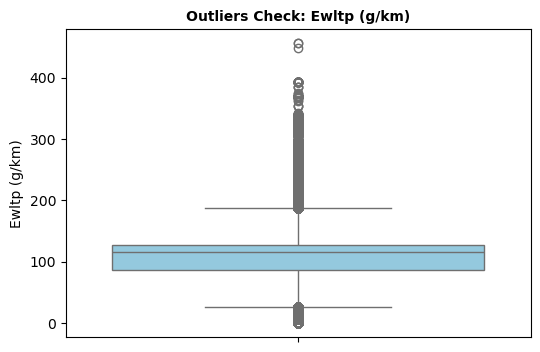

In [50]:
plt.figure(figsize=(6, 4))
sns.boxplot(y=df_clean['Ewltp (g/km)'], color='skyblue')
plt.title('Outliers Check: Ewltp (g/km)', fontsize=10, fontweight='bold')
plt.savefig('boxplot_ewltp.png', dpi=300)
plt.show()

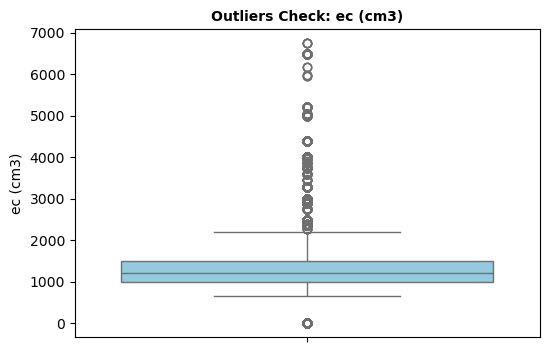

In [51]:
#Engine capacity
plt.figure(figsize=(6, 4))
sns.boxplot(y=df_clean['ec (cm3)'], color='skyblue')
plt.title('Outliers Check: ec (cm3)', fontsize=10, fontweight='bold')
plt.savefig('boxplot_ec.png', dpi=300)
plt.show()

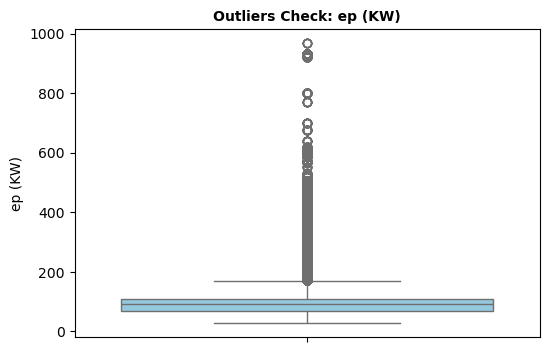

In [36]:
#Engine maximum net power output
plt.figure(figsize=(6, 4))
sns.boxplot(y=df_clean['ep (KW)'], color='skyblue')
plt.title('Outliers Check: ep (KW)', fontsize=10, fontweight='bold')
plt.savefig('boxplot_ep.png', dpi=300)
plt.show()

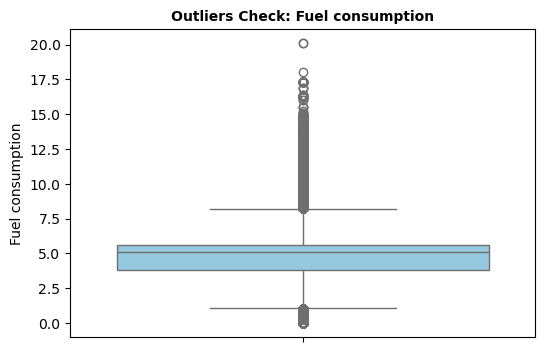

In [52]:
plt.figure(figsize=(6, 4))
sns.boxplot(y=df_clean['Fuel consumption'], color='skyblue')
plt.title('Outliers Check: Fuel consumption', fontsize=10, fontweight='bold')
plt.savefig('boxplot_fuel_consumption.png', dpi=300)
plt.show()

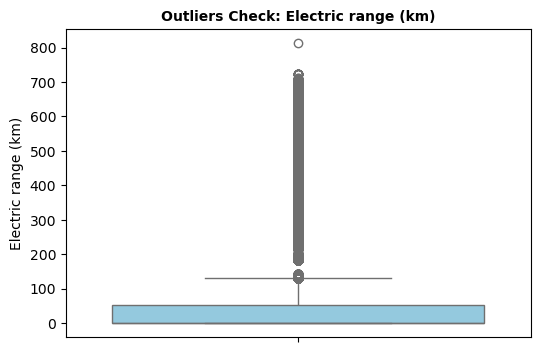

In [53]:
plt.figure(figsize=(6, 4))
sns.boxplot(y=df_clean['Electric range (km)'], color='skyblue')
plt.title('Outliers Check: Electric range (km)', fontsize=10, fontweight='bold')
plt.savefig('boxplot_electric_range.png', dpi=300)
plt.show()

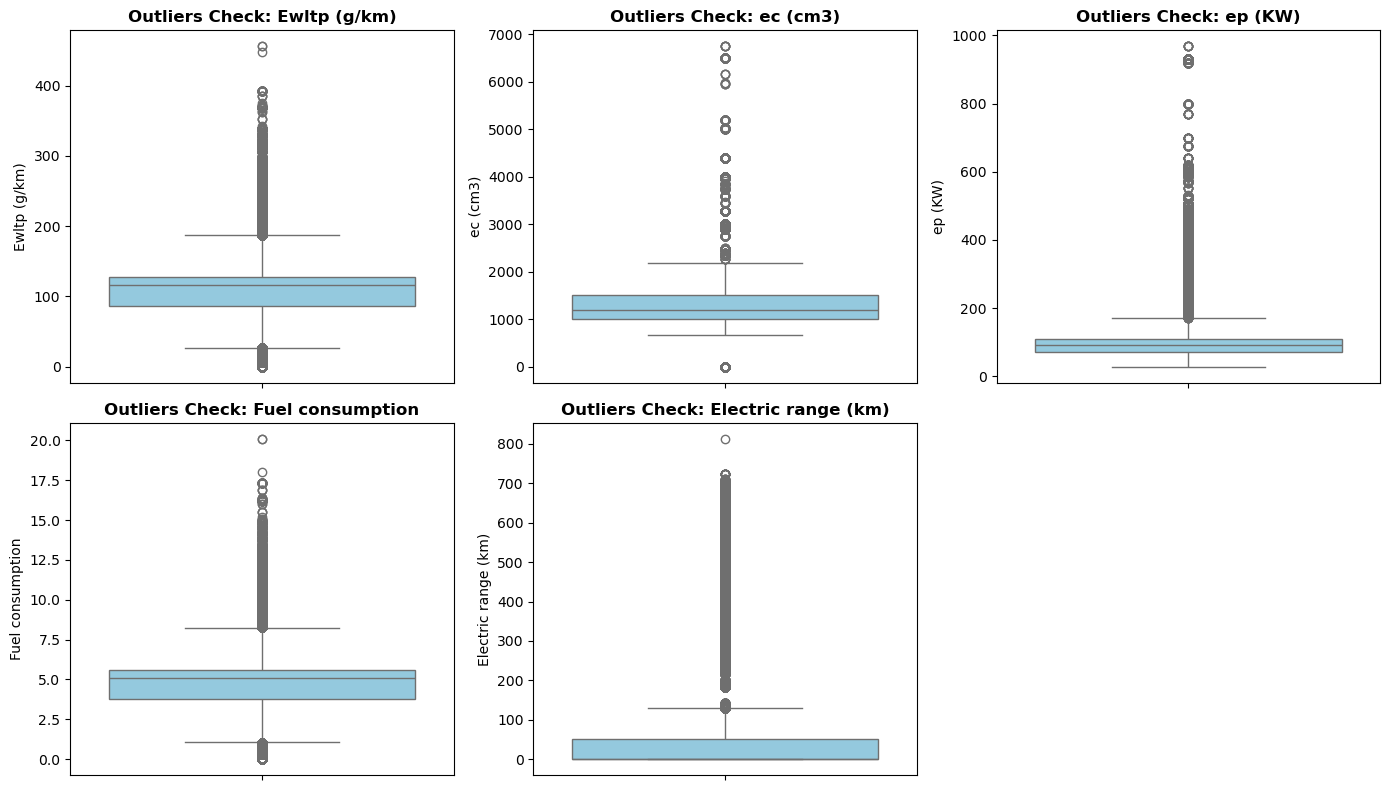

In [54]:
plt.figure(figsize=(14, 8))

# Subplot 1: CO2 Emissions
plt.subplot(2, 3, 1)
sns.boxplot(y=df_clean['Ewltp (g/km)'], color='skyblue')
plt.title('Outliers Check: Ewltp (g/km)', fontweight='bold')

# Subplot 2: Engine Size
plt.subplot(2, 3, 2)
sns.boxplot(y=df_clean['ec (cm3)'], color='skyblue')
plt.title('Outliers Check: ec (cm3)', fontweight='bold')

# Subplot 3: Power
plt.subplot(2, 3, 3)
sns.boxplot(y=df_clean['ep (KW)'], color='skyblue')
plt.title('Outliers Check: ep (KW)', fontweight='bold')

# Subplot 4: Fuel Consumption
plt.subplot(2, 3, 4)
sns.boxplot(y=df_clean['Fuel consumption'], color='skyblue')
plt.title('Outliers Check: Fuel consumption', fontweight='bold')

# Subplot 5: Electric Range
plt.subplot(2, 3, 5)
sns.boxplot(y=df_clean['Electric range (km)'], color='skyblue')
plt.title('Outliers Check: Electric range (km)', fontweight='bold')

plt.tight_layout()
plt.savefig('outliers_boxplots_individual.png', dpi=300)
plt.show()

In [55]:
#The statistical summary reveals that the dataset's extreme values reflect realistic automotive 
#domain characteristics rather than data corruption errors. 
#Engine power (ep (KW)) shows strong positive skewness (+3.51), spanning from standard commuter 
#vehicles (median of 92.0 kW) to high-performance hypercars peaking at 968.0 kW. 
#Similarly, Electric range (km) is right-skewed (+1.94) with a median of 0.0 km, illustrating that 
#while standard internal combustion engine (ICE) vehicles dominate the baseline,
#long-range electric vehicles extend up to 813.0 km. Conversely, Ewltp (g/km) emissions and 
#Fuel consumption exhibit mild negative skewness (-0.89 and -0.86, respectively), driven by the 
#cluster of zero-emission electric vehicles alongside a realistic fleet average of 116.0 g/km of CO₂ 
#and 5.1 L/100km. Because these upper-tail values represent legitimate luxury and high-performance 
#vehicle specs rather than measurement anomalies, no rows were dropped; tree-based models or 
#robust feature scaling will handle these distribution shapes effectively in the modeling phase.